# Synthetic Data Generation

Evaluate CTGAN and TVAE as synthetic data generators for the combined shelf-life dataset.
Each model is treated as an independent experiment; outputs are saved under `data/synthetic/`.

## Table of Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Conditional Matrix Sampling](#2-conditional-matrix-sampling)
3. [SDV Metadata](#3-sdv-metadata)
4. [Model Factory](#4-model-factory)
5. [Training Loop](#5-training-loop)
6. [TSTR Evaluation](#6-tstr-evaluation)
7. [Results Summary](#7-results-summary)
8. [Statistical Fidelity Check](#8-statistical-fidelity-check)

## 1. Setup and Imports

In [15]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ks_2samp

import torch
import torch.nn as nn
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths
ROOT          = Path("..").resolve()
DATA_DIR      = ROOT / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_DIR / "processed" / "combined_shelf_life.csv")
print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
df_raw.head(3)

Loaded: 964 rows x 34 cols


,experiment_id,ingredient_id,ingredient,concentration,unit_of_concentration,normalized_concentration_%_of_meat,chemical_composition,source,immersion_time,packaging_condition,...,post_threshold_count,post_inhibition_factor,post_threshold_proximity_index_2(tpi),data_source,initial_count,pre-threshold_day,pre-threshold_count,post-threshold_day,post-threshold_count,post_threshold_proximity_index
0,0,1,control,0.0,% (w/w),0.0,none,none,NaN,NaN,...,8.7,5.1,1.243,theoretical,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,anodic nacl solution,1.0,% (w/w),1.0,mineral,other natural sources,NaN,NaN,...,7.6,5.4,1.086,theoretical,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1,anodic nacl solution,1.0,% (w/w),1.0,mineral,other natural sources,NaN,NaN,...,7.5,5.2,1.071,theoretical,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_raw.columns

Index(['experiment_id', 'ingredient_id', 'ingredient', 'concentration',
       'unit_of_concentration', 'normalized_concentration_%_of_meat',
       'chemical_composition', 'source', 'immersion_time',
       'packaging_condition', 'storage_condition_(°c)', 'meat_type',
       'part_of_product', 'treatment', 'indicators', 'type_of_indicator',
       'lower_level_threshold_(log_cfu/g)',
       'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count_(day_0)',
       'pre_threshold_(day)', 'pre_threshold_count',
       'initial_inhibition_factor', 'post_threshold_(day)',
       'post_threshold_count', 'post_inhibition_factor',
       'post_threshold_proximity_index_2(tpi)', 'data_source', 'initial_count',
       'pre-threshold_day', 'pre-threshold_count', 'post-threshold_day',
       'post-threshold_count', 'post_threshold_proximity_index'],
      dtype='object')

## 2. Conditional Matrix Sampling

Right-censoring leaves `post-threshold_day`, `post-threshold_count`, `post_inhibition_factor`,
and `post_threshold_proximity_index` missing in 43-51% of rows.

A log-frequency inverse weight is computed across all categorical columns so that rare
categorical configurations are oversampled. Rows that already carry post-threshold
measurements receive an additional 2x boost, exposing the generative model to
right-censoring survivors more frequently without discarding any rows.

In [ ]:
def conditional_matrix_sample(
    df: pd.DataFrame,
    cat_cols: list[str],
    sparse_threshold: float = 0.02,
    post_threshold_cols: list[str] | None = None,
    target_n: int | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    post_threshold_cols = post_threshold_cols or []
    target_n = target_n or len(df)

    # Per-category log-frequency weights
    col_weights = np.ones(len(df))
    for col in cat_cols:
        freq = df[col].fillna('__missing__').map(
            df[col].fillna('__missing__').value_counts(normalize=True)
        ).values
        col_weights *= 1.0 / (np.log1p(freq * len(df)))

    # Post-threshold boost
    has_post = (
        df[post_threshold_cols].notna().any(axis=1).values
        if post_threshold_cols
        else np.zeros(len(df), dtype=bool)
    )
    col_weights = np.where(has_post, col_weights * 2.0, col_weights)

    # Flag sparse categories for diagnostics
    sparse_masks = {}
    for col in cat_cols:
        freq_map = df[col].fillna('__missing__').value_counts(normalize=True)
        sparse_cats = freq_map[freq_map < sparse_threshold].index.tolist()
        sparse_masks[col] = df[col].fillna('__missing__').isin(sparse_cats)

    n_sparse_rows = pd.DataFrame(sparse_masks).any(axis=1).sum()
    print(f"Rows touching at least one sparse category (<{sparse_threshold:.0%}): {n_sparse_rows}/{len(df)}")
    print(f"Rows with post-threshold data: {has_post.sum()}/{len(df)}")

    weights = col_weights / col_weights.sum()
    sampled_idx = rng.choice(len(df), size=target_n, replace=True, p=weights)
    return df.iloc[sampled_idx].reset_index(drop=True)


CAT_COLS = [c for c in [
    "ingredient", "unit_of_concentration", "chemical_composition", "source",
    "immersion_time", "packaging_condition",
    "meat_type", "part_of_product", "treatment", "indicators",
    "type_of_indicator", "unit", "data_source",
] if c in df_raw.columns]

# Include the storage condition column regardless of encoding
for _sc in ["storage_condition_(°c)", "storage_condition_(degrees_c)", "storage_condition_(?c)"]:
    if _sc in df_raw.columns and _sc not in CAT_COLS:
        CAT_COLS.append(_sc)

POST_THRESHOLD_COLS = [c for c in [
    "post-threshold_day", "post-threshold_count",
    "post_inhibition_factor", "post_threshold_proximity_index",
] if c in df_raw.columns]

df_sampled = conditional_matrix_sample(
    df_raw,
    cat_cols=CAT_COLS,
    sparse_threshold=0.02,
    post_threshold_cols=POST_THRESHOLD_COLS,
    target_n=len(df_raw),
    random_state=42,
)
print(f"\nConditionally sampled dataset: {df_sampled.shape}")
print(
    "Missing post-threshold_day after sampling:",
    df_sampled["post-threshold_day"].isna().sum(), "/", len(df_sampled),
)

Rows touching at least one sparse category (<2%): 664/964
Rows with post-threshold data: 547/964

Conditionally sampled dataset: (964, 28)
Missing post-threshold_day after sampling: 440 / 964


## 3. SDV Metadata

SDV's `SingleTableMetadata` captures the role of every column (id, categorical, numerical)
and is shared by all synthesisers.

In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_sampled)

# experiment_id and ingredient_id are identifiers, not features
metadata.update_column("experiment_id", sdtype="id")
metadata.update_column("ingredient_id", sdtype="id")

NUM_COLS = [
    "concentration", "normalized_concentration_%_of_meat",
    "lower_level_threshold_(log_cfu/g)", "upper_level_threshold_(log_cfu/g)",
    "initial_count", "pre-threshold_day", "pre-threshold_count",
    "initial_inhibition_factor", "post-threshold_day", "post-threshold_count",
    "post_inhibition_factor", "post_threshold_proximity_index",
]
for col in NUM_COLS:
    if col in df_sampled.columns:
        metadata.update_column(col, sdtype="numerical")

metadata.validate()
print("Metadata validated")
print(list(metadata.to_dict()["columns"].keys()))

Metadata validated
['experiment_id', 'ingredient_id', 'ingredient', 'concentration', 'unit_of_concentration', 'normalized_concentration_%_of_meat', 'chemical_composition', 'source', 'immersion_time', 'packaging_condition', 'storage_condition_(°c)', 'meat_type', 'part_of_product', 'treatment', 'indicators', 'type_of_indicator', 'lower_level_threshold_(log_cfu/g)', 'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count', 'pre-threshold_day', 'pre-threshold_count', 'initial_inhibition_factor', 'post-threshold_day', 'post-threshold_count', 'post_inhibition_factor', 'post_threshold_proximity_index', 'data_source']


## 4. Model Factory

Both synthesisers are built with three shared training improvements:

- **WGAN-GP** - `pac=1` disables PAC-GAN grouping so the gradient penalty is applied per individual sample.
- **TTUR** (Two Time-Scale Update Rule) - discriminator lr is set to 4x the generator lr (8e-4 vs 2e-4).
- **Spectral Normalization** - injected into every `nn.Linear` layer of the discriminator after fitting via a module-tree walk.

Adding further synthesisers requires only a new `build_*` function and one entry in the `EXPERIMENTS` dict.

In [ ]:
def _apply_spectral_norm(module: nn.Module) -> nn.Module:
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Linear):
            setattr(module, name, nn.utils.spectral_norm(child))
        else:
            _apply_spectral_norm(child)
    return module


_original_ctgan_fit = CTGANSynthesizer.fit


def _ctgan_fit_with_sn(self, data):
    _original_ctgan_fit(self, data)
    if hasattr(self, '_model') and hasattr(self._model, '_discriminator'):
        _apply_spectral_norm(self._model._discriminator)


CTGANSynthesizer.fit = _ctgan_fit_with_sn  # type: ignore[method-assign]


def build_ctgan(metadata: SingleTableMetadata, epochs: int = 300) -> CTGANSynthesizer:
    return CTGANSynthesizer(
        metadata,
        epochs=epochs,
        generator_lr=2e-4,
        generator_decay=1e-6,
        discriminator_lr=8e-4,       # TTUR: 4x generator lr
        discriminator_decay=1e-6,
        discriminator_steps=5,       # WGAN convention: more critic steps
        pac=1,                       # pac=1 -> per-sample gradient penalty
        batch_size=500,
        verbose=True,
    )


def build_tvae(metadata: SingleTableMetadata, epochs: int = 300) -> TVAESynthesizer:
    return TVAESynthesizer(
        metadata,
        epochs=epochs,
        batch_size=500,
        lr=2e-4,
        l2scale=1e-5,
    )


print("Model factory ready.")

Model factory ready.


## 5. Training Loop

Each model is an independent experiment. After fitting, it generates `len(df_raw)` synthetic
rows and saves them to `data/synthetic/<model_name>.csv`.

In [ ]:
EPOCHS      = 300
N_SYNTHETIC = len(df_raw)

EXPERIMENTS = {
    "ctgan": build_ctgan(metadata, epochs=EPOCHS)
}

synthetic_datasets: dict[str, pd.DataFrame] = {}

for name, synth in EXPERIMENTS.items():
    print(f"\n{'='*60}")
    print(f"  Training {name.upper()} ({EPOCHS} epochs)")
    print(f"{'='*60}")
    t0 = time.time()
    synth.fit(df_sampled)
    print(f"  -> Fit complete in {(time.time() - t0) / 60:.1f} min")

    df_syn = synth.sample(num_rows=N_SYNTHETIC)
    out_path = SYNTHETIC_DIR / f"{name}.csv"
    df_syn.to_csv(out_path, index=False)
    synthetic_datasets[name] = df_syn
    print(f"  -> Saved {N_SYNTHETIC} rows to {out_path}")

print("\nAll experiments complete.")


  Training CTGAN (300 epochs)


Gen. (+01.16) | Discrim. (-02.08): 100%|██████████| 300/300 [01:51<00:00,  2.70it/s]


  -> Fit complete in 2.0 min
  -> Saved 964 rows to C:\Users\safae\projects\ML\data\synthetic\ctgan.csv

All experiments complete.


## 6. TSTR Evaluation

**Train on Synthetic, Test on Real** protocol.

Target: `post_threshold_proximity_index` - a continuous score capturing how far a preservation
outcome has crossed the upper safety threshold.

- **Baseline** - trained on real data, tested on a fixed 20% real hold-out.
- **CTGAN / TVAE** - trained on the corresponding synthetic dataset, tested on the same hold-out.

Metrics: RMSE, MAE, R².

In [ ]:
TARGET = "post_threshold_proximity_index"

DROP_COLS    = ["experiment_id", "ingredient_id", TARGET]
FEATURE_COLS = [c for c in df_raw.columns if c not in DROP_COLS]
CAT_FEATURES = [c for c in FEATURE_COLS if df_raw[c].dtype == "object"]
NUM_FEATURES = [c for c in FEATURE_COLS if c not in CAT_FEATURES]


def make_pipeline() -> Pipeline:
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_FEATURES),
        ("num", "passthrough", NUM_FEATURES),
    ])
    model = HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, max_depth=6, random_state=42,
    )
    return Pipeline([("pre", pre), ("model", model)])


def evaluate(pipe: Pipeline, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = pipe.predict(X_test)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAE":  float(mean_absolute_error(y_test, y_pred)),
        "R2":   float(r2_score(y_test, y_pred)),
    }


def prepare_split(df: pd.DataFrame):
    d = df.dropna(subset=[TARGET]).copy()
    return d[FEATURE_COLS], d[TARGET]


# Fixed real 80/20 split - identical across all experiments
X_real, y_real = prepare_split(df_raw)
X_train_real, X_test, y_train_real, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42,
)

results: dict[str, dict] = {}

# Baseline: real -> real
pipe_real = make_pipeline()
pipe_real.fit(X_train_real, y_train_real)
results["real (baseline)"] = evaluate(pipe_real, X_test, y_test)
print("Baseline (real -> real):", results["real (baseline)"])

# Synthetic experiments: synthetic -> real
for name, df_syn in synthetic_datasets.items():
    X_syn, y_syn = prepare_split(df_syn)
    pipe_syn = make_pipeline()
    pipe_syn.fit(X_syn, y_syn)
    results[name] = evaluate(pipe_syn, X_test, y_test)
    print(f"{name.upper()} (syn -> real):", results[name])

Baseline (real -> real): {'RMSE': 0.4392343884631831, 'MAE': 0.14209114153552832, 'R2': 0.88841688640628}
CTGAN (syn -> real): {'RMSE': 1.3167726338651133, 'MAE': 0.6424172944595008, 'R2': -0.002830169655529957}


## 7. Results Summary

In [ ]:
baseline_rmse = results["real (baseline)"]["RMSE"]

df_results = (
    pd.DataFrame(results).T
    .rename_axis("experiment")
    .reset_index()
)
df_results["RMSE_vs_baseline_%"] = (
    (df_results["RMSE"] - baseline_rmse) / baseline_rmse * 100
).round(1)
df_results = df_results.sort_values("RMSE").round(4)

print("\n=== TSTR Results (sorted by RMSE) ===")
print(df_results.to_string(index=False))

df_results.to_csv(SYNTHETIC_DIR / "tstr_results.csv", index=False)
print(f"\nSaved to {SYNTHETIC_DIR / 'tstr_results.csv'}")


=== TSTR Results (sorted by RMSE) ===
     experiment   RMSE    MAE      R2  RMSE_vs_baseline_%
real (baseline) 0.4392 0.1421  0.8884                 0.0
          ctgan 1.3168 0.6424 -0.0028               199.8

Saved to C:\Users\safae\projects\ML\data\synthetic\tstr_results.csv


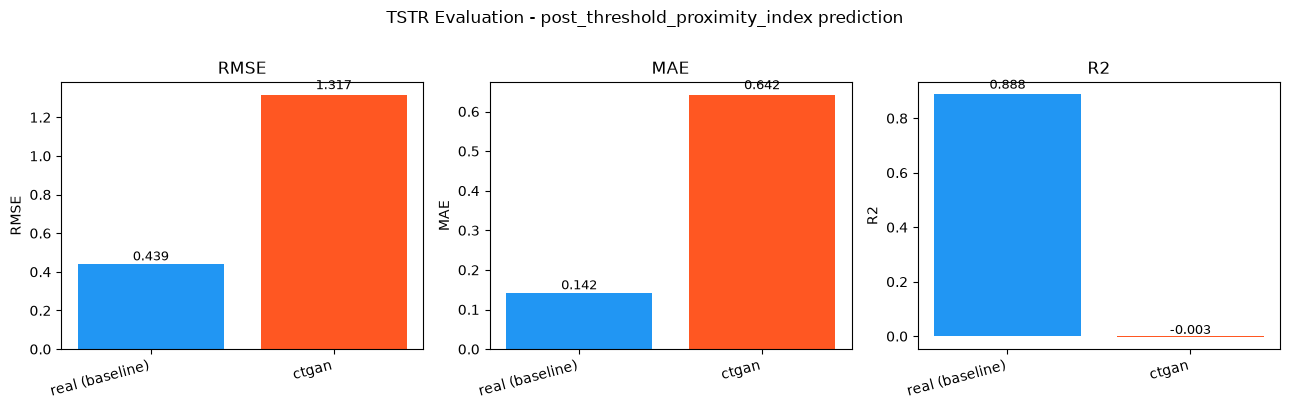

Plot saved.


In [ ]:
metrics = ["RMSE", "MAE", "R2"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#2196F3", "#FF5722", "#4CAF50"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_results["experiment"], df_results[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(df_results["experiment"], rotation=15, ha="right")
    for bar, val in zip(bars, df_results[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )

fig.suptitle(
    "TSTR Evaluation - post_threshold_proximity_index prediction",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(SYNTHETIC_DIR / "tstr_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 8. Statistical Fidelity Check

Column-wise KS statistics between real and synthetic numerical distributions.
Lower values indicate better marginal fidelity, independently of predictive utility.

In [ ]:
def ks_fidelity(df_real: pd.DataFrame, df_syn: pd.DataFrame) -> pd.Series:
    stats = {}
    for col in NUM_FEATURES:
        if col not in df_syn.columns:
            continue
        r = df_real[col].dropna()
        s = df_syn[col].dropna()
        if len(r) < 2 or len(s) < 2:
            continue
        stat, _ = ks_2samp(r, s)
        stats[col] = round(stat, 4)
    return pd.Series(stats, name="KS statistic")


ks_rows = {name: ks_fidelity(df_raw, df_syn) for name, df_syn in synthetic_datasets.items()}
df_ks = pd.DataFrame(ks_rows)
df_ks.loc["mean"] = df_ks.mean()

print("=== KS Statistics (lower = better) ===")
print(df_ks.to_string())
df_ks.to_csv(SYNTHETIC_DIR / "ks_fidelity.csv")
print(f"\nSaved to {SYNTHETIC_DIR / 'ks_fidelity.csv'}")

=== KS Statistics (lower = better) ===
                                     ctgan
concentration                       0.2332
normalized_concentration_%_of_meat  0.2742
lower_level_threshold_(log_cfu/g)   0.4276
upper_level_threshold_(log_cfu/g)   0.3882
initial_count                       0.0618
pre-threshold_day                   0.3278
pre-threshold_count                 0.2660
initial_inhibition_factor           0.2267
post-threshold_day                  0.5584
post-threshold_count                0.2587
post_inhibition_factor              0.4600
mean                                0.3166

Saved to C:\Users\safae\projects\ML\data\synthetic\ks_fidelity.csv
